In [12]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.datasets import mnist
from tensorflow.keras.layers import Dense
from tensorflow.keras.models import Sequential


In [13]:
(x_train,_),(x_test,_)=mnist.load_data()
x_train=x_train.astype('float32')/255.0
x_test=x_test.astype('float32')/255.0
x_train=x_train.reshape(-1,784)
x_test=x_test.reshape(-1,784)

In [21]:
def add_noise(data):
    noise=0.5*np.random.normal(0,1,data.shape)
    return np.clip(noise+data,0.,1.)


In [35]:
model=Sequential([
    Dense(128,activation='relu',input_shape=(784,)),
    Dense(32,activation='relu'),
     Dense(64,activation='relu'),
    Dense(784,activation='sigmoid')
])

model.compile(loss='binary_crossentropy',optimizer='adam')
model.fit(add_noise(x_train),x_train,epochs=10,batch_size=64,verbose=1)

/Users/muskansingh/.pyenv/versions/3.11.5/lib/python3.11/site-packages/keras/src/layers/core/dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - loss: 0.2003
Epoch 2/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 0.1520
Epoch 3/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 0.1435
Epoch 4/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 0.1388
Epoch 5/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 0.1352
Epoch 6/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - loss: 0.1326
Epoch 7/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 0.1305
Epoch 8/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 0.1290
Epoch 9/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 0.1278
Epoch 10/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 0.1267


In [34]:
loss=model.evaluate(add_noise(x_test),x_test,verbose=1)
print(f"Reconstruction Loss: {round(loss,4)}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.1219
Reconstruction Loss: 0.1219


In [27]:
reconstructed=model.predict(x_test[:5])


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step


In [31]:
x_test_noisy=add_noise(x_test)

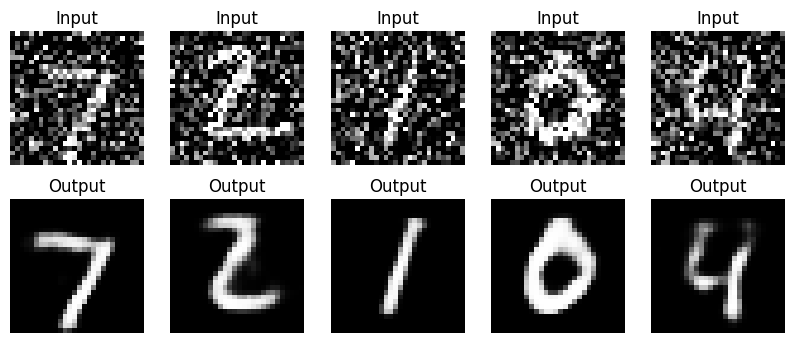

In [33]:
plt.figure(figsize=(10,4))
for i in range(5):
    plt.subplot(2,5,i+1)
    plt.imshow(x_test_noisy[i].reshape(28,28),cmap='gray')
    plt.title("Input")
    plt.axis('off')
    plt.subplot(2,5,i+6)
    plt.imshow(reconstructed[i].reshape(28,28),cmap='gray')
    plt.title("Output")
    plt.axis('off')
plt.show()
